# KG-R1 Implementation Test

Testing the four basic graph operations from the KG-R1 paper reference.

## 1. Build a Simple Knowledge Graph

In [1]:
import networkx as nx

# create a directed knowledge graph
G = nx.DiGraph()

triples = [
    ("The Honest Woodcutter", "written_by", "Aesop"),
    ("The Honest Woodcutter", "moral_theme", "Honesty"),
    ("Aesop", "published_by", "Classic Tales Press"),
    ("Aesop", "born_in", "Greece"),
    ("Greece", "continent", "Europe")
]

for h, r, t in triples:
    G.add_edge(h, t, relation=r)

print("Nodes:", list(G.nodes()))
print("Edges:", [(u, v, G[u][v]['relation']) for u, v in G.edges()])

Nodes: ['The Honest Woodcutter', 'Aesop', 'Honesty', 'Classic Tales Press', 'Greece', 'Europe']
Edges: [('The Honest Woodcutter', 'Aesop', 'written_by'), ('The Honest Woodcutter', 'Honesty', 'moral_theme'), ('Aesop', 'Classic Tales Press', 'published_by'), ('Aesop', 'Greece', 'born_in'), ('Greece', 'Europe', 'continent')]


## 2. Define the Four Basic Graph Operations

In [2]:
def get_tail_relations(entity):
    """Relations where entity is the head (outgoing)."""
    return [G[entity][t]['relation'] for t in G.successors(entity)]

def get_head_relations(entity):
    """Relations where entity is the tail (incoming)."""
    return [G[h][entity]['relation'] for h in G.predecessors(entity)]

def get_tail_entities(entity, relation):
    """All tails connected by a given relation."""
    return [t for t in G.successors(entity) if G[entity][t]['relation'] == relation]

def get_head_entities(entity, relation):
    """All heads connected by a given relation."""
    return [h for h in G.predecessors(entity) if G[h][entity]['relation'] == relation]

## 3. Simulate a Multi-Turn "Agent" Query Loop

In [3]:
# start from a natural-language question (for simulation)
question = "Where was the author of 'The Honest Woodcutter' born?"

print(f"Question: {question}")

# Step 1: identify the author of the book
relations = get_tail_relations("The Honest Woodcutter")
print("\nRelations for 'The Honest Woodcutter':", relations)

author = get_tail_entities("The Honest Woodcutter", "written_by")[0]
print("Found author:", author)

# Step 2: find where the author was born
birth_place = get_tail_entities(author, "born_in")[0]
print("Birthplace:", birth_place)

# Step 3: find which continent that place is in
continent = get_tail_entities(birth_place, "continent")[0]
print("Continent:", continent)

# Final Answer
print(f"\nAnswer: The author of 'The Honest Woodcutter' was born in {birth_place}, {continent}.")

Question: Where was the author of 'The Honest Woodcutter' born?

Relations for 'The Honest Woodcutter': ['written_by', 'moral_theme']
Found author: Aesop
Birthplace: Greece
Continent: Europe

Answer: The author of 'The Honest Woodcutter' was born in Greece, Europe.


## 4. Visualize the Graph

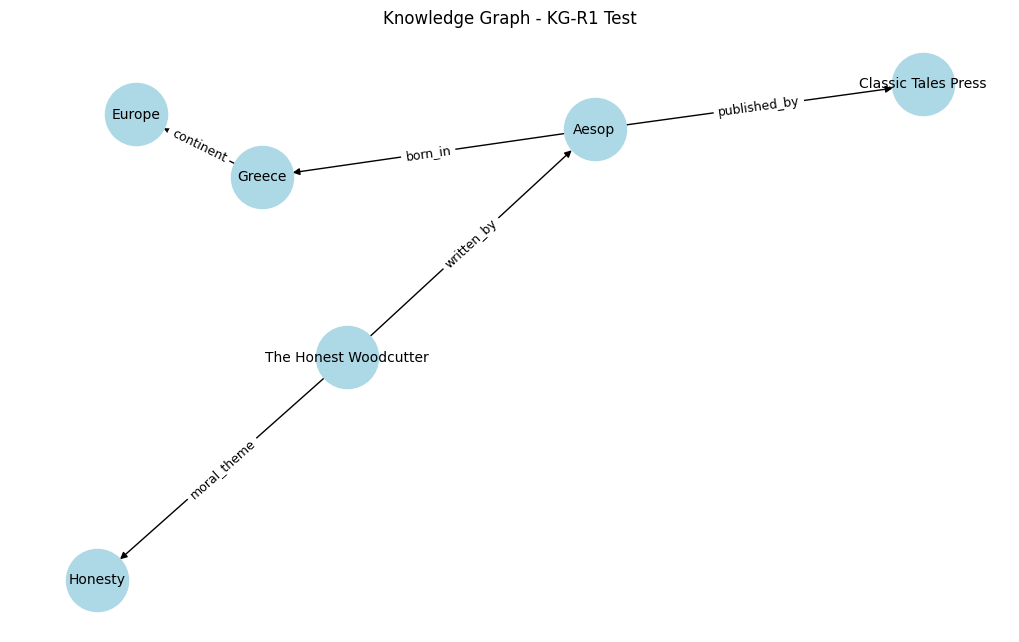

In [4]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)
edge_labels = nx.get_edge_attributes(G, 'relation')

plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2000, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
plt.title("Knowledge Graph - KG-R1 Test")
plt.show()

## 5. Test All Four Operations

In [5]:
# Test each operation
print("Testing KG-R1 Operations:")
print("\n1. get_tail_relations('Aesop'):", get_tail_relations("Aesop"))
print("2. get_head_relations('Greece'):", get_head_relations("Greece"))
print("3. get_tail_entities('Aesop', 'born_in'):", get_tail_entities("Aesop", "born_in"))
print("4. get_head_entities('Aesop', 'written_by'):", get_head_entities("Aesop", "written_by"))

Testing KG-R1 Operations:

1. get_tail_relations('Aesop'): ['published_by', 'born_in']
2. get_head_relations('Greece'): ['born_in']
3. get_tail_entities('Aesop', 'born_in'): ['Greece']
4. get_head_entities('Aesop', 'written_by'): ['The Honest Woodcutter']
